# Connect to google drive

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Connect to database

In [9]:
import os

folder_path = '/content/drive/MyDrive/rice leaf'
print(os.listdir(folder_path))


['rice leaf-1']


# Import libraries

In [13]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# Unnecessary warnings ignore

In [14]:
import warnings
warnings.filterwarnings("ignore")

# Loads, preprocesses, and labels

In [17]:
import cv2
import os

IMAGE_SIZE = (224, 224)
DATA_DIR = "/content/drive/MyDrive/rice leaf/rice leaf-1/rice leaf/"

X = []
y = []

for category in os.listdir(DATA_DIR):
    category_dir = os.path.join(DATA_DIR, category)

    for image_file in os.listdir(category_dir):
        image_path = os.path.join(category_dir, image_file)

        img = cv2.imread(image_path)
        # Check if the image was loaded successfully before resizing
        if img is not None:
            img = cv2.resize(img, IMAGE_SIZE)
            img = img.astype('float32') / 255.0
            X.append(img)

            if category == "tungro":
                y.append(0)
            elif category == "blast":
                y.append(1)
            elif category == "blight":
                y.append(2)
        else:
            print(f"Warning: Could not load image: {image_path}")

X = np.array(X)
y = np.array(y)


print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (240, 224, 224, 3)
y shape: (240,)


# Model traning

In [ ]:
import cv2
import os
import numpy as np # Ensure numpy is imported
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- Code to define X and y (originally from ggRwzlDyec4z) ---
IMAGE_SIZE = (224, 224)
DATA_DIR = "/content/drive/MyDrive/rice leaf/rice leaf-1/rice leaf/"

X = []
y = []

for category in os.listdir(DATA_DIR):
    category_dir = os.path.join(DATA_DIR, category)

    for image_file in os.listdir(category_dir):
        image_path = os.path.join(category_dir, image_file)

        img = cv2.imread(image_path)
        # Check if the image was loaded successfully before resizing
        if img is not None:
            img = cv2.resize(img, IMAGE_SIZE)
            img = img.astype('float32') / 255.0
            X.append(img)

            if category == "tungro":
                y.append(0)
            elif category == "blast":
                y.append(1)
            elif category == "blight":
                y.append(2)
        else:
            print(f"Warning: Could not load image: {image_path}")

X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)
# --- End of code from ggRwzlDyec4z ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes: tungro, blast, blight
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


X shape: (240, 224, 224, 3)
y shape: (240,)
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3854 - loss: 3.6768 - val_accuracy: 0.3958 - val_loss: 1.1036
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4010 - loss: 1.1335 - val_accuracy: 0.3125 - val_loss: 1.1131
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4323 - loss: 1.0676 - val_accuracy: 0.5625 - val_loss: 0.9837
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5677 - loss: 0.9596 - val_accuracy: 0.5000 - val_loss: 1.0490
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5625 - loss: 0.8792 - val_accuracy: 0.7292 - val_loss: 0.7578
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6458 - loss: 0.7722 - val_accuracy: 0.6875 - val_loss: 0.7720
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7708 - loss: 0.5967 - val_accuracy: 0.6667 - val_loss: 0.6506
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8281 - loss: 0.4599 - val_

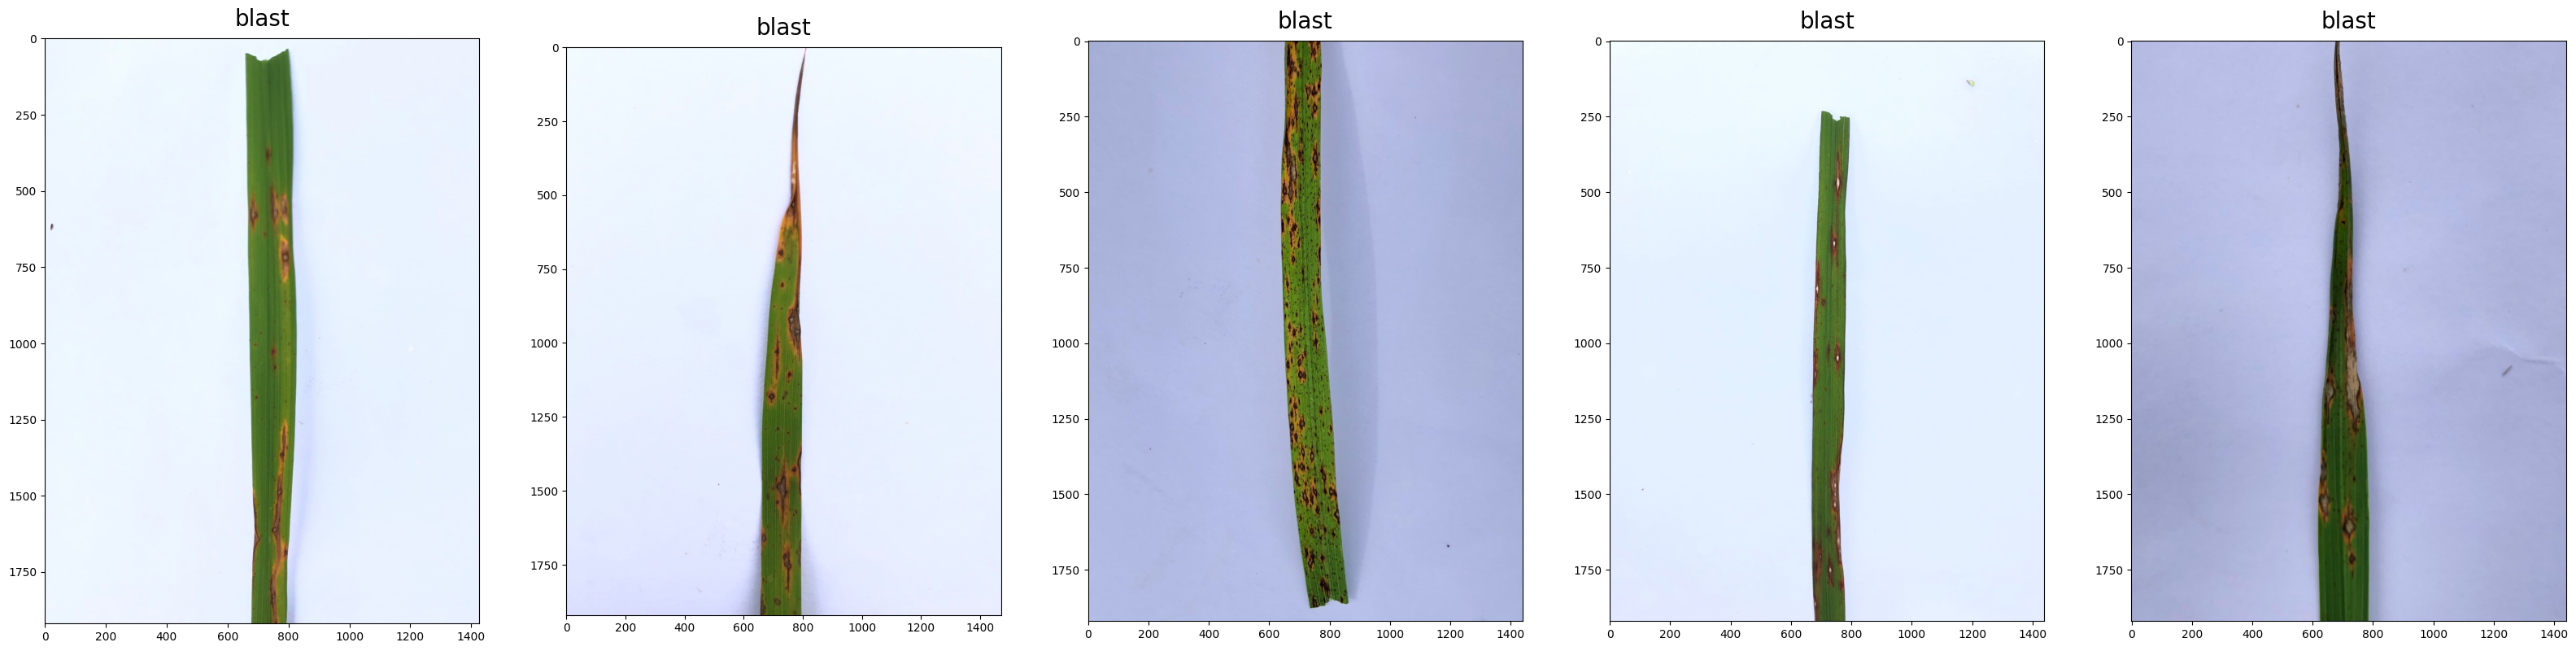

In [25]:
import matplotlib.pyplot as plt # Import the plotting library
import os # Import os module for path manipulation

select_vegetable="blast" # Changed to an existing folder name in the dataset (e.g., 'tungro', 'blast', 'blight')
rows,columns = 1,5

# Use DATA_DIR from the previous image loading step
test_folder = "/content/drive/MyDrive/rice leaf/rice leaf-1/rice leaf/"

display_folder=os.path.join(test_folder,select_vegetable) # Use test_folder which is '/content/images'
total_images=rows*columns
fig=plt.figure(1, figsize=(40, 10))

for i,j in enumerate(os.listdir(display_folder)):

    img = plt.imread(os.path.join(display_folder,j)) # Image path relative to display_folder
    fig=plt.subplot(rows, columns, i+1)
    fig.set_title(select_vegetable, pad = 11, size=20)
    plt.imshow(img)

    if i==total_images-1:
        break